## Predição de Acidente Vascular Cerebral

O código abaixo utiliza um dataset obtido de https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset com dados sobre ocorrências e não-ocorrências de Acidentes Vasculares Cerebrais (AVC) entre pessoas de 0 a 82 anos. O objetivo final foi desenvolver um classificador, baseado nas caracterísiticas apresentadas no dataset, que determinasse se o referido paciente teve ou não um AVC. Para tanto, com vistas a possibilitar decisões mais acertadas na escolha do modelo, anteriormente à etapa de treino e teste foram realizados procedimentos de limpeza e tratamento, bem como uma breve análise exploratória.

O modelo escolhido foi uma **Árvore de Decisão** (***Decision Tree***) com profundidade máxima 30.



In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Carregando a versão mais recente dos dados
path = kagglehub.dataset_download(
  "fedesoriano/stroke-prediction-dataset",

)

print(f'path to files: {path}')

Using Colab cache for faster access to the 'stroke-prediction-dataset' dataset.
path to files: /kaggle/input/stroke-prediction-dataset


In [ ]:
import seaborn as sns
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score


In [ ]:
df = pd.read_csv('/kaggle/input/stroke-prediction-dataset/healthcare-dataset-stroke-data.csv')
df.head()


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## Limpeza e Tratamento de dados
Para melhor utilizar todos os dados presentes na planilha, bem como determinar sua correlação e relevância, são interessantes as práticas de


1. Mitigar valores nulos com a alternativa mais apropriada à situação  
2. Transformar dados não-numéricos em formato numérico (casting, one-hot-encoding)
  



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


Inicialmente, será realizado um tratamento dos dados nulos.

In [ ]:
df.isna().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201


Observa-se que a única coluna com nulos é a 'bmi'. Seus dados são numéricos. Preencher os nulos com zero, valor de máximo ou de mínimo poderia desregular o modelo. Apagar as linhas correspodentes  seria uma boa ideia, pois somente 201 dados seriam descartados, 4% do total. Todavia, os valores NaN serão substituídos pela média geral da coluna.

<Axes: ylabel='bmi'>

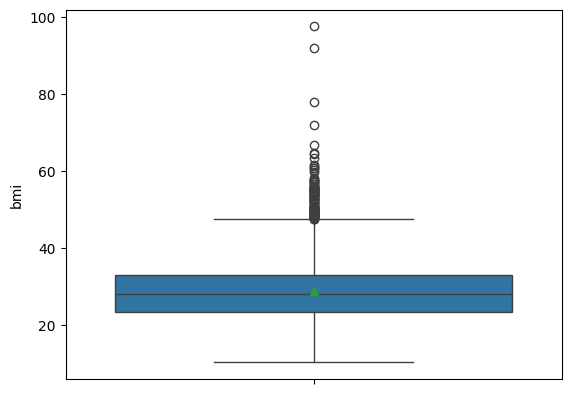

In [ ]:
sns.boxplot(df['bmi'], showmeans=True)

In [ ]:
df['bmi']  = df['bmi'].fillna(df['bmi'].mean(numeric_only=True))

In [ ]:
df.isna().sum()

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0


In [ ]:
df['bmi']

,bmi
0,36.600000
1,28.893237
2,32.500000
3,34.400000
4,24.000000
...,...
5105,28.893237
5106,40.000000
5107,30.600000
5108,25.600000


Inserção de one-hot-encoding para a coluna gender. Isto permitirá que a esse dados seja codificado numéricamente e, portanto, processado pelos modelos de machine learning que serão posteriormente usados.

In [ ]:
df.gender.unique()

array(['Male', 'Female', 'Other'], dtype=object)

In [ ]:
# df['male'] = (df['gender'] == 'Male').astype(np.int64) não é recomendado criar as três colunas, pois pode causar multicolinearidade
df['female'] = (df['gender'] == 'Female').astype(np.int64)
df['other'] = (df['gender'] == 'Other').astype(np.int64)

Transformando a coluna 'ever_married' para int. Mesmo motivo da transformação anterior.

In [ ]:
mask = df['ever_married'] == 'Yes'
df['ever_married'] = mask.astype(np.int64)

In [ ]:
df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,female,other
0,9046,Male,67.0,0,1,1,Private,Urban,228.69,36.600000,formerly smoked,1,0,0
1,51676,Female,61.0,0,0,1,Self-employed,Rural,202.21,28.893237,never smoked,1,1,0
2,31112,Male,80.0,0,1,1,Private,Rural,105.92,32.500000,never smoked,1,0,0
3,60182,Female,49.0,0,0,1,Private,Urban,171.23,34.400000,smokes,1,1,0
4,1665,Female,79.0,1,0,1,Self-employed,Rural,174.12,24.000000,never smoked,1,1,0
5,56669,Male,81.0,0,0,1,Private,Urban,186.21,29.000000,formerly smoked,1,0,0
6,53882,Male,74.0,1,1,1,Private,Rural,70.09,27.400000,never smoked,1,0,0
7,10434,Female,69.0,0,0,0,Private,Urban,94.39,22.800000,never smoked,1,1,0
8,27419,Female,59.0,0,0,1,Private,Rural,76.15,28.893237,Unknown,1,1,0
9,60491,Female,78.0,0,0,1,Private,Urban,58.57,24.200000,Unknown,1,1,0


Agora, de modo mais conciso, todas as colunas não-numéricas restantes passarão por one-hot encoding.

In [ ]:
df = pd.get_dummies(df, columns=['work_type', 'Residence_type',  'smoking_status'], drop_first=True)

In [ ]:
df.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'avg_glucose_level', 'bmi', 'stroke', 'female', 'other',
       'work_type_Never_worked', 'work_type_Private',
       'work_type_Self-employed', 'work_type_children', 'Residence_type_Urban',
       'smoking_status_formerly smoked', 'smoking_status_never smoked',
       'smoking_status_smokes'],
      dtype='object')

In [ ]:
df[['work_type_Never_worked', 'work_type_Private',
       'work_type_Self-employed', 'work_type_children', 'Residence_type_Urban',
       'smoking_status_formerly smoked', 'smoking_status_never smoked',
       'smoking_status_smokes']] = df[['work_type_Never_worked', 'work_type_Private',
       'work_type_Self-employed', 'work_type_children', 'Residence_type_Urban',
       'smoking_status_formerly smoked', 'smoking_status_never smoked',
       'smoking_status_smokes']].astype(np.int64)

In [ ]:
df = df.drop(columns='gender')
df

,id,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,stroke,female,other,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,9046,67.0,0,1,1,228.69,36.600000,1,0,0,0,1,0,0,1,1,0,0
1,51676,61.0,0,0,1,202.21,28.893237,1,1,0,0,0,1,0,0,0,1,0
2,31112,80.0,0,1,1,105.92,32.500000,1,0,0,0,1,0,0,0,0,1,0
3,60182,49.0,0,0,1,171.23,34.400000,1,1,0,0,1,0,0,1,0,0,1
4,1665,79.0,1,0,1,174.12,24.000000,1,1,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,80.0,1,0,1,83.75,28.893237,0,1,0,0,1,0,0,1,0,1,0
5106,44873,81.0,0,0,1,125.20,40.000000,0,1,0,0,0,1,0,1,0,1,0
5107,19723,35.0,0,0,1,82.99,30.600000,0,1,0,0,0,1,0,0,0,1,0
5108,37544,51.0,0,0,1,166.29,25.600000,0,0,0,0,1,0,0,0,1,0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              5110 non-null   int64  
 1   age                             5110 non-null   float64
 2   hypertension                    5110 non-null   int64  
 3   heart_disease                   5110 non-null   int64  
 4   ever_married                    5110 non-null   int64  
 5   avg_glucose_level               5110 non-null   float64
 6   bmi                             5110 non-null   float64
 7   stroke                          5110 non-null   int64  
 8   female                          5110 non-null   int64  
 9   other                           5110 non-null   int64  
 10  work_type_Never_worked          5110 non-null   int64  
 11  work_type_Private               5110 non-null   int64  
 12  work_type_Self-employed         51

A etapa de tratamento de dados está finalizada. Agora, pode-se prosseguir para a etapa analítica.

### Análise Exploratória e detecção de outliers




<Axes: >

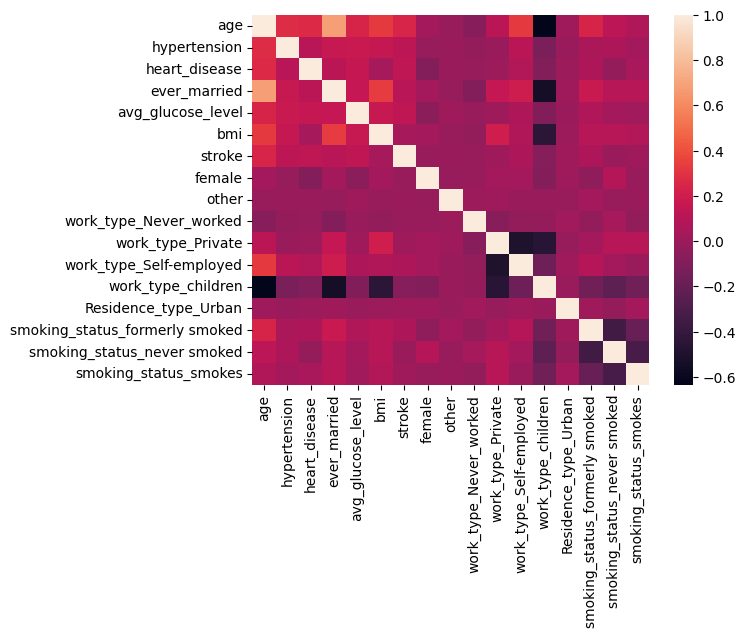

In [ ]:
mask = df.columns[df.columns != 'id']
corr = df[mask].corr()

sns.heatmap(corr)

Text(0.5, 1.0, 'Age vs. stroke')

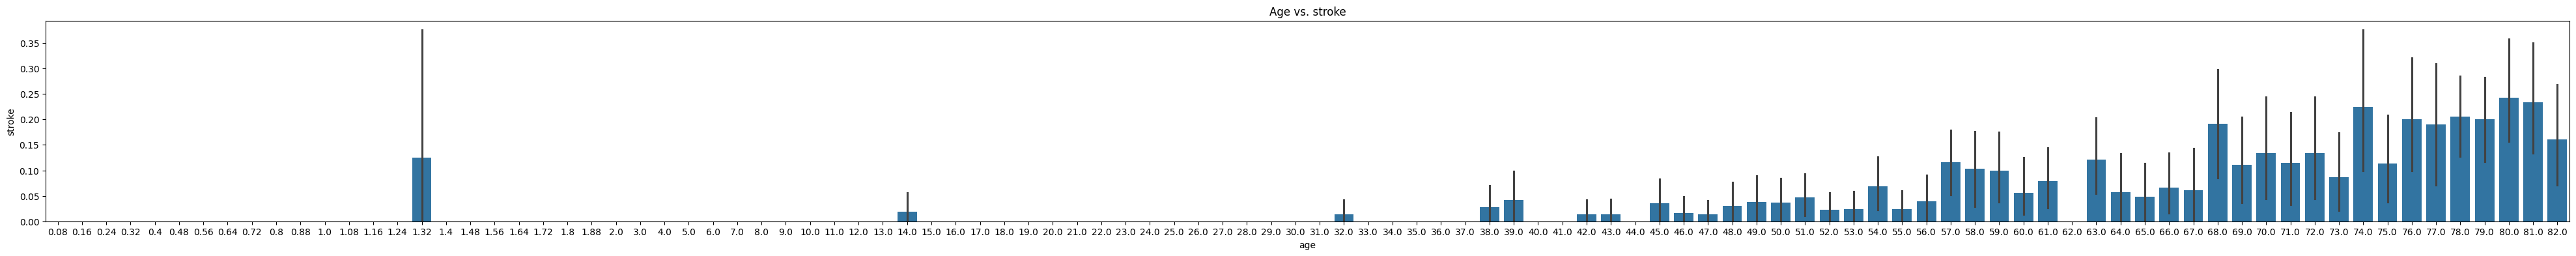

In [ ]:
plt.figure(figsize=(50,4))
sns.barplot(data=df, x='age', y='stroke')
plt.title('Age vs. stroke')

Text(0.5, 1.0, 'Age of people who had an stroke')

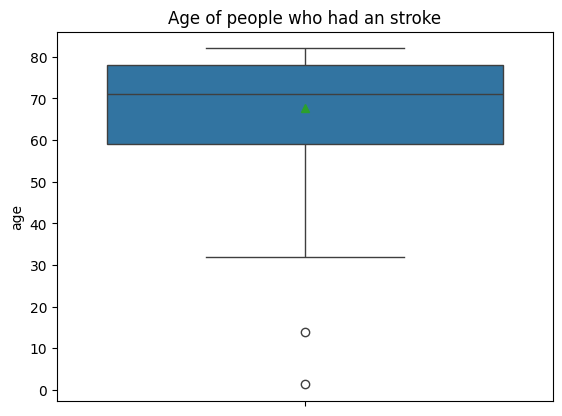

In [ ]:
sns.boxplot(df[df['stroke'] == True]['age'], showmeans=True)
plt.title('Age of people who had an stroke')

Pode-se observar que há dois *outliers*. Para melhorar o desempenho do modelo, podemos deletá-los.

In [ ]:
q1 = df[df['stroke'] == 1]['age'].quantile(0.25)
q3 = df[df['stroke'] == 1]['age'].quantile(0.75)

iqr = q3 - q1

lower = q1 - 1.5*iqr
upper = q3 + 1.5*iqr

df[((df['stroke'] == 1) & ((df['age'] < lower)|(df['age'] > upper)))]

,id,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,stroke,female,other,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
162,69768,1.32,0,0,0,70.37,28.893237,1,1,0,0,0,0,1,1,0,0,0
245,49669,14.00,0,0,0,57.93,30.900000,1,1,0,0,0,0,1,0,0,0,0


In [ ]:
df = df[~((df['stroke'] == 1) & ((df['age'] < lower)|(df['age'] > upper)))]

Text(0.5, 1.0, 'Age vs. hypertension')

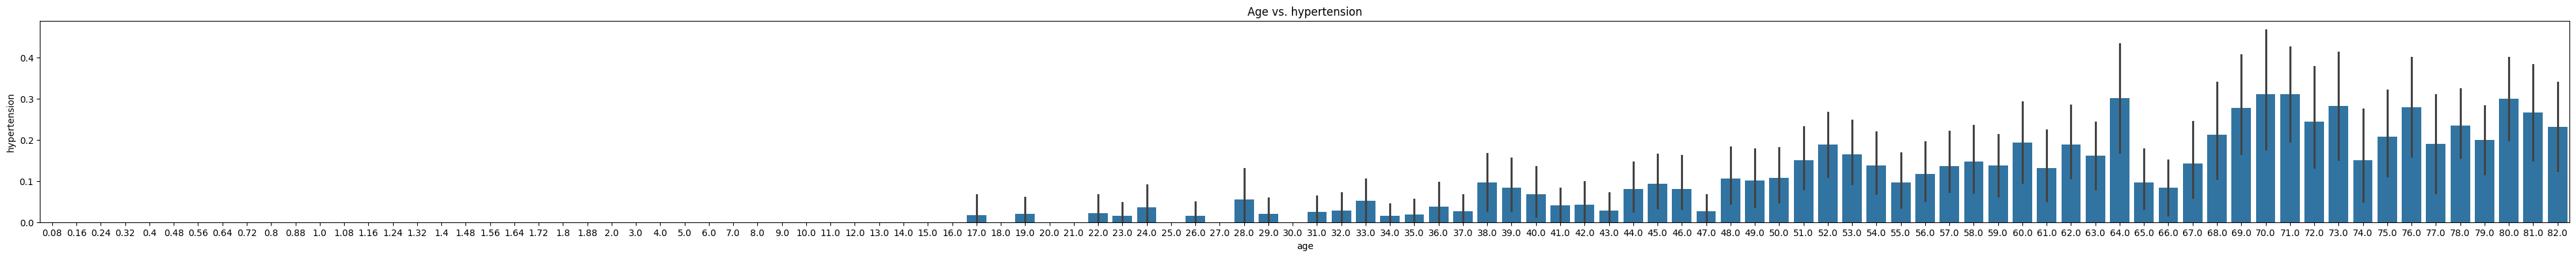

In [ ]:
plt.figure(figsize=(50,4))
sns.barplot(data=df, x='age', y='hypertension')
plt.title('Age vs. hypertension')

<Axes: ylabel='age'>

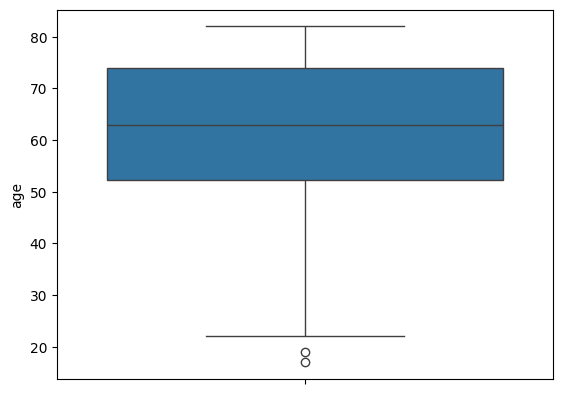

In [ ]:
sns.boxplot(df[df['hypertension'] == True]['age'])

In [ ]:
q1 = df[df['hypertension'] == True]['age'].quantile(0.25)
q2 = df[df['hypertension'] == True]['age'].quantile(0.75)

iqr = q2 - q1

lower = q1 - 1.5*iqr
upper = q2 + 1.5*iqr

df = df[~((df['hypertension']==True) & ((df['age'] > upper )|(df['age'] < lower)))]

<Axes: xlabel='age', ylabel='Count'>

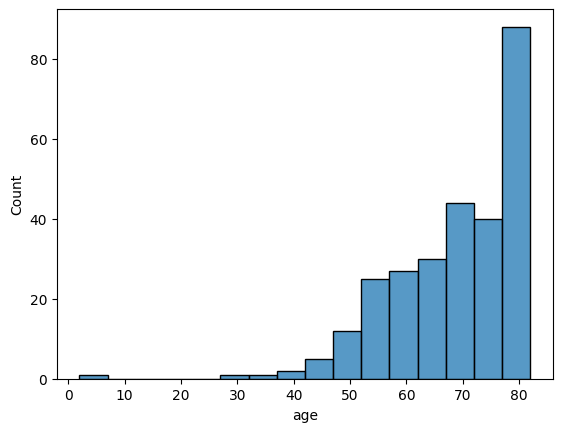

In [ ]:
sns.histplot(df[df['heart_disease'] == True]['age'])

<Axes: ylabel='age'>

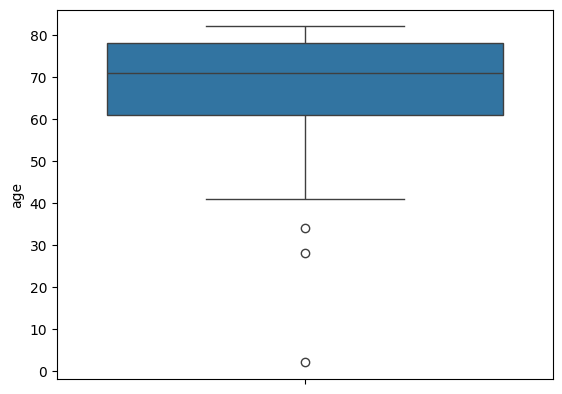

In [ ]:
sns.boxplot(df[df['heart_disease'] == True]['age'])

In [ ]:
q1 = df[df['heart_disease'] == True]['age'].quantile(0.25)
q2 = df[df['heart_disease'] == True]['age'].quantile(0.75)

iqr = q2 - q1

lower = q1 - 1.5*iqr
upper = q2 + 1.5*iqr

df = df[~((df['heart_disease']==True) & ((df['age'] > upper )|(df['age'] < lower)))]

Text(0.5, 1.0, 'Age vs. avg_glucose_level')

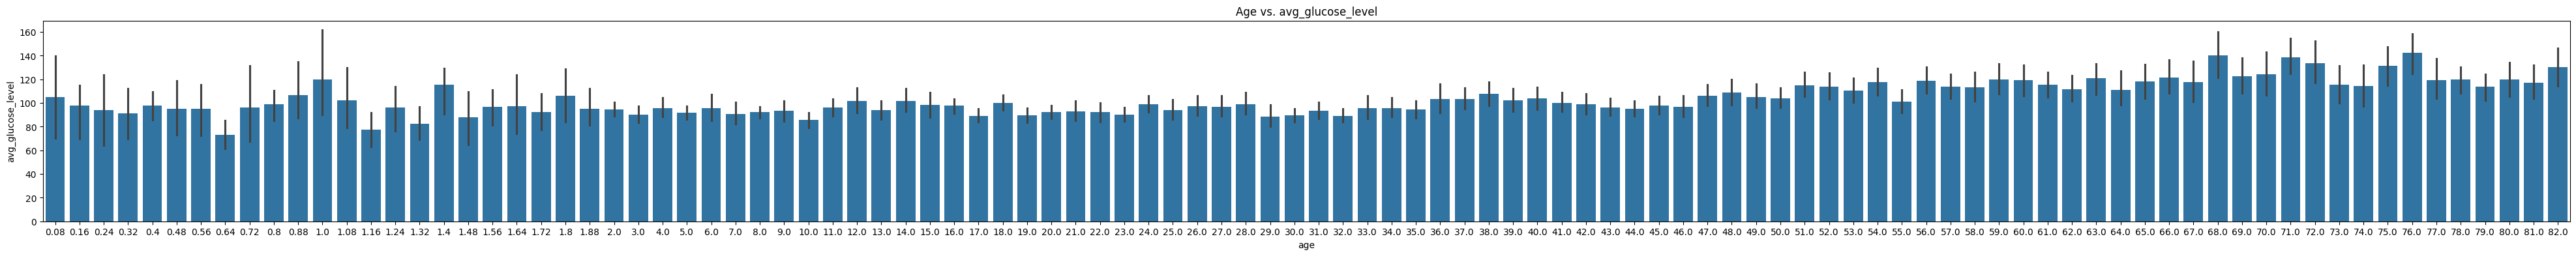

In [ ]:
plt.figure(figsize=(50,4))
sns.barplot(data=df, x='age', y='avg_glucose_level')
plt.title('Age vs. avg_glucose_level')

Acima, observa-se que os casos de AVC estão aproximadamente em proporção direta com a idade, bem como a ocorrência de hipertensão. A média de glicose no sangue é aproximadamente a mesma para todas as faixas etárias, com um leve aumento para idosos.

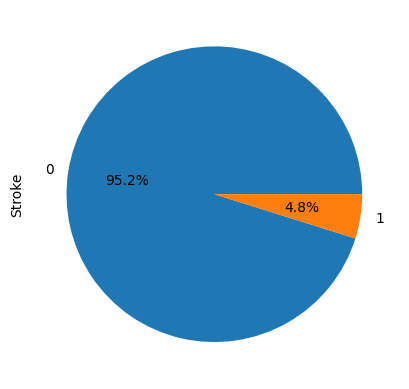

In [ ]:
counts = df['stroke'].value_counts()

counts.plot.pie(autopct='%1.1f%%')
plt.ylabel('Stroke')
plt.show()

Percebe-se que a proporção de casos positivos é muito pequena.

In [ ]:
print(f'Média de glicose no sangue para pacientes que tiveram AVC: {int(np.mean(df[df['stroke'] == 1]['avg_glucose_level']))}. Desvio padrão: {np.std(df[df['stroke'] == 1]['avg_glucose_level'])}')
print(f'Média de glicose no sangue para pacientes que NÃO tiveram AVC: {int(np.mean(df[df['stroke'] == 0]['avg_glucose_level']))}. Desvio padrão: {np.std(df[df['stroke'] == 0]['avg_glucose_level'])}')

Média de glicose no sangue para pacientes que tiveram AVC: 133. Desvio padrão: 61.7352659034957
Média de glicose no sangue para pacientes que NÃO tiveram AVC: 104. Desvio padrão: 43.851983767857256


In [ ]:
np.std(df[df['stroke'] == 1]['avg_glucose_level'])
np.std(df[df['stroke'] == 0]['avg_glucose_level'])

43.851983767857256

E, por fim, nota-se que a glicose no sangue para pessoas que tiveram um AVC costuma ser maior do que para pessoas que não o tiveram. Entretanto, ocorre um grande desvio padrão entre as amostras.

In [ ]:
df.sample()

,id,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,stroke,female,other,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
895,7122,41.0,0,0,0,94.3,41.6,0,1,0,0,1,0,0,0,0,0,0


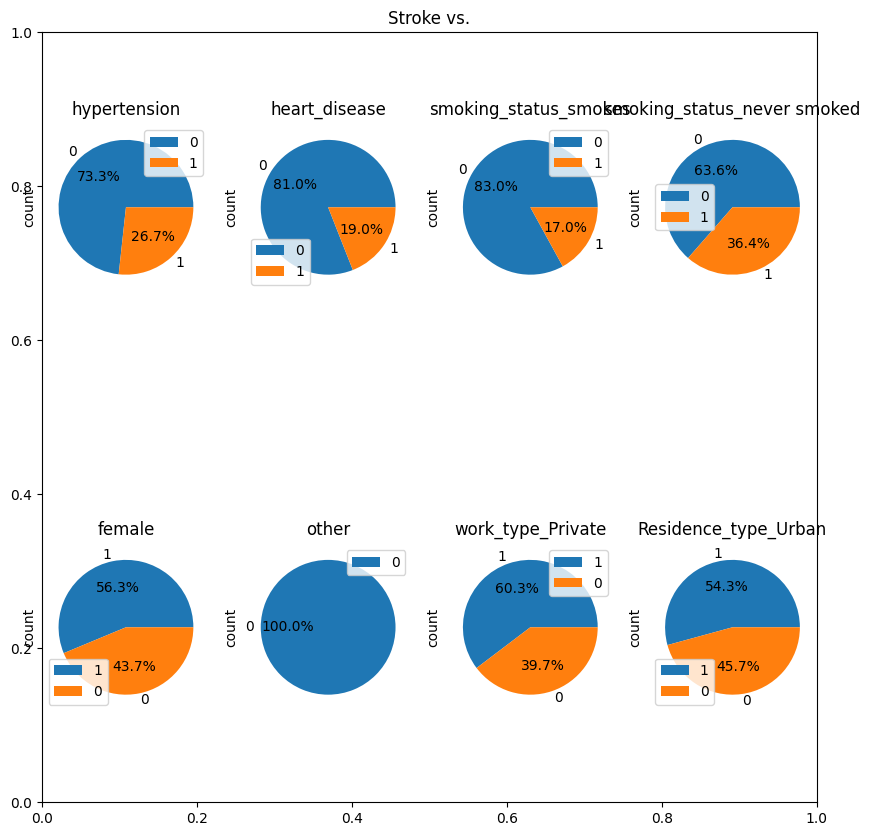

In [ ]:
def proporcao(column):
  return df[df['stroke'] == True][column].value_counts()

plt.figure(figsize=(10,10))
plt.title('Stroke vs.')

plt.subplot(241)
proporcao('hypertension').plot.pie(autopct='%1.1f%%')
plt.title('hypertension')
plt.legend()

plt.subplot(242)
proporcao('heart_disease').plot.pie(autopct='%1.1f%%')
plt.title('heart_disease')
plt.legend()

plt.subplot(243)
proporcao('smoking_status_smokes').plot.pie(autopct='%1.1f%%')
plt.title('smoking_status_smokes')
plt.legend()

plt.subplot(244)
proporcao('smoking_status_never smoked').plot.pie(autopct='%1.1f%%')
plt.title('smoking_status_never smoked')
plt.legend()

plt.subplot(245)
proporcao('female').plot.pie(autopct='%1.1f%%')
plt.title('female')
plt.legend()

plt.subplot(246)
proporcao('other').plot.pie(autopct='%1.1f%%')
plt.title('other')
plt.legend()

plt.subplot(247)
proporcao('work_type_Private').plot.pie(autopct='%1.1f%%')
plt.title('work_type_Private')
plt.legend()

plt.subplot(248)
proporcao('Residence_type_Urban').plot.pie(autopct='%1.1f%%')
plt.title('Residence_type_Urban')
plt.legend()

### Verificando tipo de distribuição dos dados

Text(0.5, 1.0, 'avg_glucose_level')

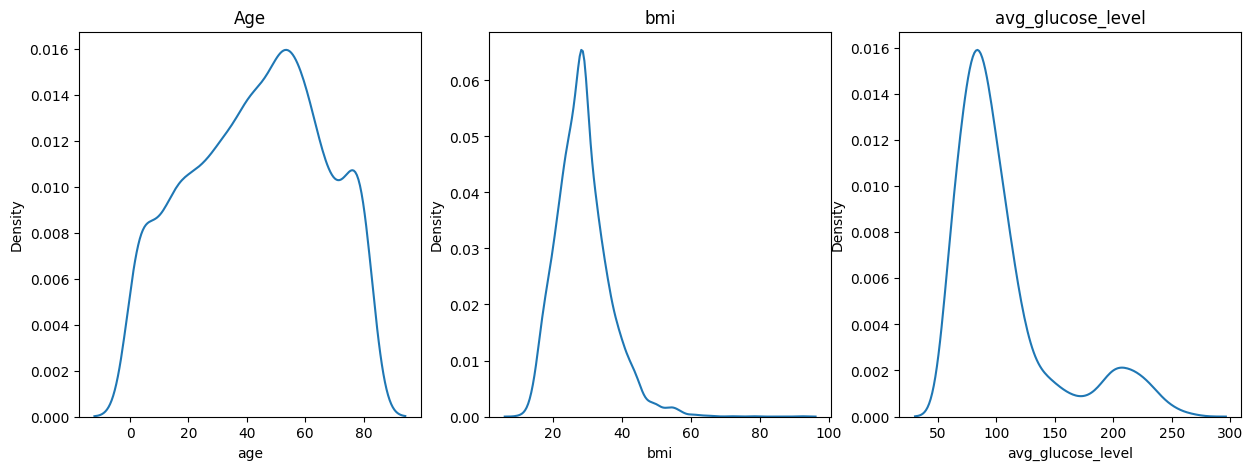

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(131)
sns.kdeplot(df['age'])
plt.title('Age')

plt.subplot(132)
sns.kdeplot(df['bmi'])
plt.title('bmi')

plt.subplot(133)
sns.kdeplot(df['avg_glucose_level'])
plt.title('avg_glucose_level')


Observa-se que a distribuição dos dados quantitativos não é normal. Não é indicado, nesse caso, utilizar a correlação de Pearson.

## Classificação: Decision Tree

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

O dataset apresenta diversas colunas e a utilização de todas elas poderia acarretar overfitting e confundir as ações do modelo. Por esse motivo, foram realizados testes com diferentes conjuntos de colunas, com vistas a consolidar uma decisão mais acertada. Por fim, selecionados apenas algumas colunas estratégicas para que resultaram na maior precisão.

Além disso, **precisão**, não acurácia, foi a métrica utilizada, dada a proporção da ocorrência/não ocorrência da variável alvo, apenas 4,9%.  

Por conta da ampla presença de variáveis categóricas no dataset, o modelo de classificação escolhido foi **Decision Tree**.

In [ ]:
from sklearn.tree import DecisionTreeClassifier


X = df.drop(columns=['stroke', 'id'])
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=42
)

In [ ]:
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=8, min_samples_leaf=3,
                       n_estimators=300, random_state=42)

Precisão: 0.140625
              precision    recall  f1-score   support

           0       0.98      0.77      0.87       972
           1       0.14      0.73      0.24        49

    accuracy                           0.77      1021
   macro avg       0.56      0.75      0.55      1021
weighted avg       0.94      0.77      0.84      1021



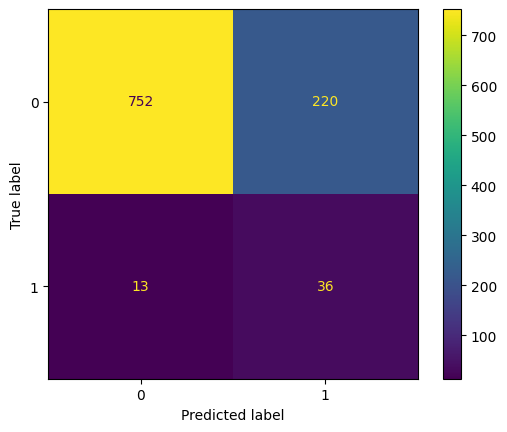

In [ ]:
threshold = 0.4
y_probs = model.predict_proba(X_test)[:,1]
preds = (y_probs > threshold).astype(int)

print(f'Precisão: {precision_score(y_true=y_test, y_pred=preds)}')
ConfusionMatrixDisplay.from_predictions(y_test, preds)

print(classification_report(y_test, preds))


### Ajustando modelo pela importância das features


In [ ]:
feature_imp= pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
feature_imp

,0
age,0.476737
avg_glucose_level,0.157128
bmi,0.126363
ever_married,0.050008
hypertension,0.032597
work_type_children,0.028046
work_type_Self-employed,0.024062
heart_disease,0.023530
female,0.015494
smoking_status_never smoked,0.015287


In [ ]:
selected_features = feature_imp[feature_imp > 0.05].index.to_list()
selected_features

['age', 'avg_glucose_level', 'bmi', 'ever_married']

In [ ]:
X_train = X_train[selected_features]
X_test = X_test[selected_features]

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=8, min_samples_leaf=3,
                       n_estimators=300, random_state=42)

Precisão: 0.15463917525773196
              precision    recall  f1-score   support

           0       0.98      0.83      0.90       972
           1       0.15      0.61      0.25        49

    accuracy                           0.82      1021
   macro avg       0.57      0.72      0.57      1021
weighted avg       0.94      0.82      0.87      1021



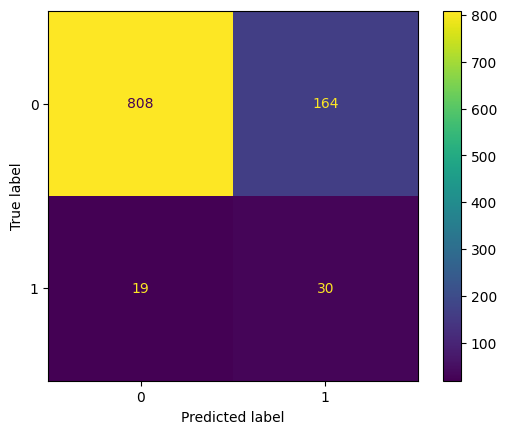

In [ ]:
threshold = 0.45
y_probs = model.predict_proba(X_test)[:,1]
preds = (y_probs > threshold).astype(int)

print(f'Precisão: {precision_score(y_true=y_test, y_pred=preds)}')
ConfusionMatrixDisplay.from_predictions(y_test, preds)

print(classification_report(y_test, preds))


### Voltando para todas as features originais, porém retirando as com pouca variância

In [ ]:
X.columns

Index(['age', 'hypertension', 'heart_disease', 'ever_married',
       'avg_glucose_level', 'bmi', 'female', 'other', 'work_type_Never_worked',
       'work_type_Private', 'work_type_Self-employed', 'work_type_children',
       'Residence_type_Urban', 'smoking_status_formerly smoked',
       'smoking_status_never smoked', 'smoking_status_smokes'],
      dtype='object')

In [ ]:
from sklearn.feature_selection import VarianceThreshold

var = VarianceThreshold(threshold=0.15)
cols_selecionadas  = var.fit_transform(X)

mask = var.get_feature_names_out().tolist() # quais colunas foram mantidas

X_train, X_test, y_train, y_test = train_test_split(X[mask], y, test_size=0.2, stratify=y, random_state=42)

Precisão: 0.16666666666666666
              precision    recall  f1-score   support

           0       0.98      0.83      0.90       972
           1       0.17      0.67      0.27        49

    accuracy                           0.82      1021
   macro avg       0.57      0.75      0.58      1021
weighted avg       0.94      0.82      0.87      1021



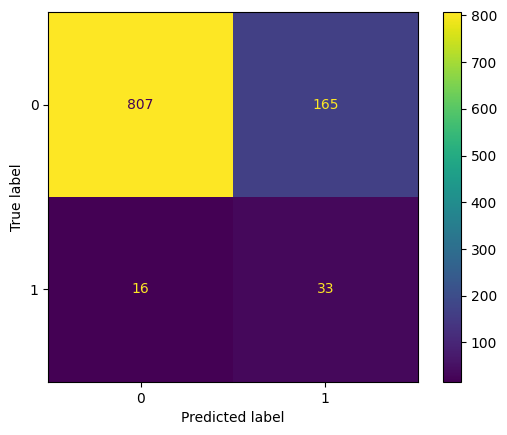

In [ ]:
model.fit(X_train, y_train)

threshold = 0.45
y_probs = model.predict_proba(X_test)[:,1]
preds = (y_probs > threshold).astype(int)

print(f'Precisão: {precision_score(y_true=y_test, y_pred=preds)}')
ConfusionMatrixDisplay.from_predictions(y_test, preds)

print(classification_report(y_test, preds))

### Utilizando Boruta para selecionar features

In [ ]:
!pip install Boruta

In [ ]:
from boruta import BorutaPy

boruta = BorutaPy(estimator=model,
                  n_estimators='auto',
                  max_iter=100,
                  random_state=42)

In [ ]:
boruta.fit(X.values, y.values)
features_imp = X.columns[boruta.support_].tolist()
features_imp

['age', 'avg_glucose_level', 'bmi']

Precisão: 0.14705882352941177
              precision    recall  f1-score   support

           0       0.98      0.82      0.89       972
           1       0.15      0.61      0.24        49

    accuracy                           0.81      1021
   macro avg       0.56      0.72      0.56      1021
weighted avg       0.94      0.81      0.86      1021



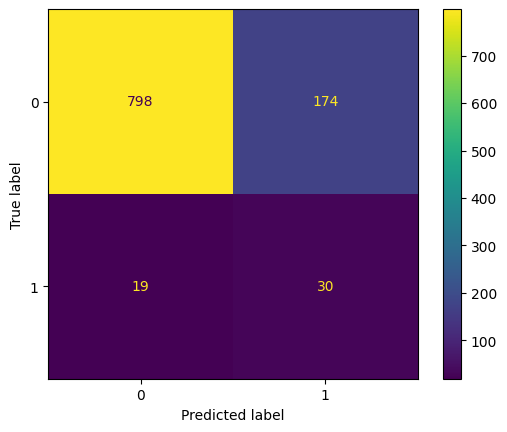

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X[features_imp], y, test_size=0.2, stratify=y, random_state=42)

model.fit(X_train, y_train)

threshold = 0.45
y_probs = model.predict_proba(X_test)[:,1]
preds = (y_probs > threshold).astype(int)

print(f'Precisão: {precision_score(y_true=y_test, y_pred=preds)}')
ConfusionMatrixDisplay.from_predictions(y_test, preds)

print(classification_report(y_test, preds))

### Utilizando Cross-Validation

No código anterior, foi descoberto que precisão não parece ser uma boa métrica para o caso, então substituiu-se por f1-score.

In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=3,
    class_weight='balanced',
    random_state=42
) # continua sendo o mesmo modelo

# cross-validation

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    model, X_train, y_train, cv=skf, scoring='f1'
)

print('CV f1 scores: ', cv_scores)
print('Média de f1-score:', np.mean(cv_scores))

CV f1 scores:  [0.20895522 0.23776224 0.21917808 0.23776224 0.31724138]
Média de f1-score: 0.24417983218143963


              precision    recall  f1-score   support

           0       0.99      0.68      0.80       972
           1       0.11      0.82      0.20        49

    accuracy                           0.69      1021
   macro avg       0.55      0.75      0.50      1021
weighted avg       0.94      0.69      0.78      1021

f1: 0.19950124688279303


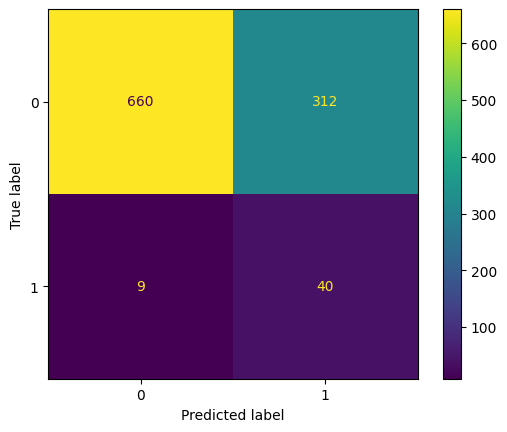

In [ ]:
model.fit(X_train, y_train)

y_probs = model.predict_proba(X_test)[:, 1]

threshold = 0.3

y_pred = (y_probs > threshold).astype(int)
''

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

print(classification_report(y_test, y_pred))
print("f1:", f1_score(y_test, y_pred))

In [ ]:
feature_imp= pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
feature_imp

,0
age,0.476737
avg_glucose_level,0.157128
bmi,0.126363
ever_married,0.050008
hypertension,0.032597
work_type_children,0.028046
work_type_Self-employed,0.024062
heart_disease,0.023530
female,0.015494
smoking_status_never smoked,0.015287


In [ ]:
features = feature_imp[feature_imp > 0.02].index.tolist()
features

['age',
 'avg_glucose_level',
 'bmi',
 'ever_married',
 'hypertension',
 'work_type_children',
 'work_type_Self-employed',
 'heart_disease']

In [ ]:
X_train = X_train[features]
X_test = X_test[features]


skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    model, X_train, y_train, cv=skf, scoring='f1'
)

print('CV f1 scores: ', cv_scores)
print('Média de f1-score:', np.mean(cv_scores))

CV f1 scores:  [0.22360248 0.23225806 0.25925926 0.27218935 0.27906977]
Média de f1-score: 0.2532757849603449


              precision    recall  f1-score   support

           0       0.98      0.65      0.78       972
           1       0.10      0.80      0.18        49

    accuracy                           0.66      1021
   macro avg       0.54      0.72      0.48      1021
weighted avg       0.94      0.66      0.75      1021

f1: 0.1822429906542056


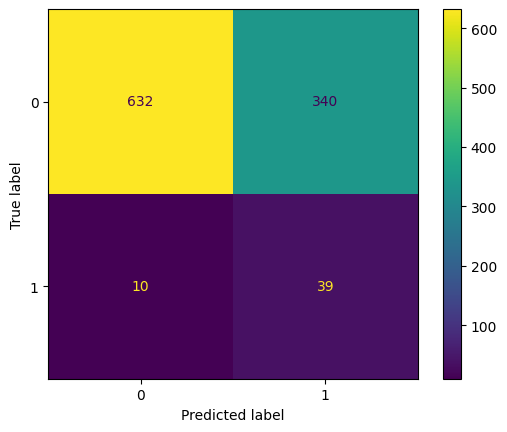

In [ ]:
model.fit(X_train, y_train)

y_probs = model.predict_proba(X_test)[:, 1]

threshold = 0.3

y_pred = (y_probs > threshold).astype(int)


ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

print(classification_report(y_test, y_pred))
print("f1:", f1_score(y_test, y_pred))

O modelo desenvolvido apresentou desempenho consistente ao lidar com um conjunto de dados desbalanceado, especialmente após ajuste do threshold de decisão. A utilização de métricas como precisão e F1-score permitiu uma avaliação mais adequada do problema.